# 03. GTX-A 역 거리와 승차인원 상관분석

H3 8 공급구조 유지 셀을 대상으로 최근접 GTX-A 역까지의 거리와 개통 전후 승차인원 증감의 관계를 분석한다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h3

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
BASE = Path.cwd()
if BASE.name == 'Analysis': BASE = BASE.parent
OUTPUT_DIR = BASE / 'Analysis' / 'output'
stable = pd.read_csv(OUTPUT_DIR / 'h3_8_stable_supply_demand_change.csv', encoding='utf-8-sig')
print(f'분석 셀 수: {len(stable)}개')
display(stable.head())

분석 셀 수: 71개


,H3 셀,2024 승차인원,2025 승차인원,승차인원 증감
0,8830e0a407fffff,9,14,5
1,8830e0a419fffff,31,11,-20
2,8830e0a41dfffff,211,165,-46
3,8830e0a423fffff,14,8,-6
4,8830e0a42bfffff,25,10,-15


In [2]:
gtx_stations = pd.DataFrame({'역명': ['운정중앙', '킨텍스', '대곡'], 'lat': [37.716670, 37.665000, 37.631626], 'lon': [126.728330, 126.748060, 126.811024]})
def h3_center(cell):
    return h3.cell_to_latlng(cell) if hasattr(h3, 'cell_to_latlng') else h3.h3_to_geo(cell)
def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlon / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))
centers = stable['H3 셀'].map(h3_center)
stable[['셀 중심 위도', '셀 중심 경도']] = pd.DataFrame(centers.tolist(), index=stable.index)
distance_matrix = pd.DataFrame({station['역명']: haversine_km(stable['셀 중심 위도'], stable['셀 중심 경도'], station['lat'], station['lon']) for _, station in gtx_stations.iterrows()})
stable['최근접 GTX-A역'] = distance_matrix.idxmin(axis=1)
stable['최근접 GTX-A역 거리(km)'] = distance_matrix.min(axis=1)
display(stable[['H3 셀', '최근접 GTX-A역', '최근접 GTX-A역 거리(km)', '승차인원 증감']].head())

,H3 셀,최근접 GTX-A역,최근접 GTX-A역 거리(km),승차인원 증감
0,8830e0a407fffff,대곡,1.202172,5
1,8830e0a419fffff,대곡,3.096557,-20
2,8830e0a41dfffff,대곡,2.365996,-46
3,8830e0a423fffff,대곡,1.905106,-6
4,8830e0a42bfffff,대곡,1.132523,-15


## 상관분석 및 시각화

Pearson과 Spearman 상관계수를 계산한다. 상관계수는 거리와 승차인원의 연관성을 보여주며 인과관계를 의미하지 않는다.

,승차인원 지표,표본 수,Pearson 상관계수,Spearman 상관계수
0,승차인원 증감,71,0.247,0.391


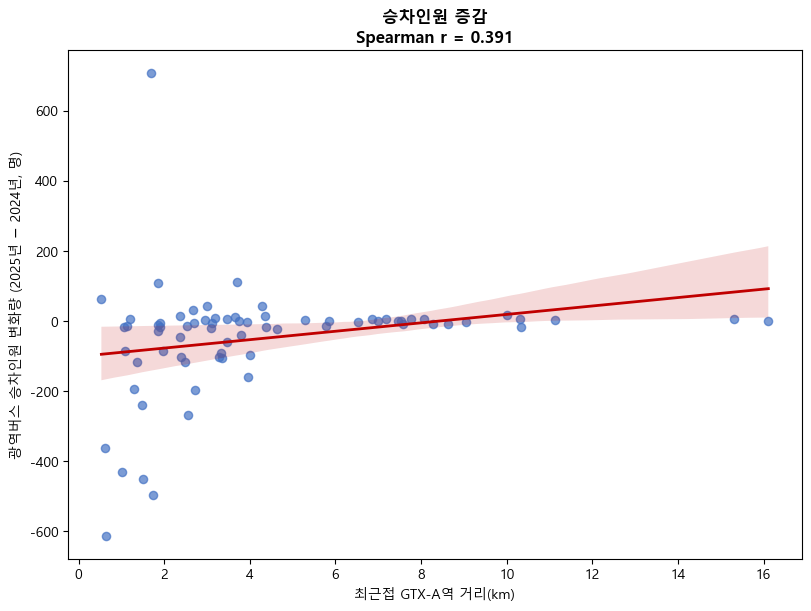

In [3]:
distance_col = '최근접 GTX-A역 거리(km)'
demand_cols = ['승차인원 증감']
Y_LABEL = '광역버스 승차인원 변화량 (2025년 − 2024년, 명)'
rows = []
for col in demand_cols:
    pair = stable[[distance_col, col]].dropna()
    rows.append({'승차인원 지표': col, '표본 수': len(pair), 'Pearson 상관계수': pair[distance_col].corr(pair[col], method='pearson'), 'Spearman 상관계수': pair[distance_col].corr(pair[col], method='spearman')})
correlation_summary = pd.DataFrame(rows)
display(correlation_summary.round(3))

for col in demand_cols:
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    sns.regplot(data=stable, x=distance_col, y=col, ax=ax, scatter_kws={'s': 35, 'alpha': 0.7, 'color': '#4472C4'}, line_kws={'color': '#C00000', 'linewidth': 2})
    r = stable[distance_col].corr(stable[col], method='spearman')
    ax.set_title(f'{col}\nSpearman r = {r:.3f}', fontweight='bold')
    ax.set_xlabel('최근접 GTX-A역 거리(km)')
    ax.set_ylabel(Y_LABEL)
    plt.show()

## 회귀분석

셀별 승차인원 증감을 종속변수로 두고, 최근접 GTX-A 역까지의 거리를 설명변수로 하는 단순 선형회귀를 수행한다. HC3 강건 표준오차를 함께 사용한다.

In [4]:
import statsmodels.api as sm
regression_rows = []
for outcome in ['승차인원 증감']:
    reg_data = stable[[distance_col, outcome]].dropna()
    X = sm.add_constant(reg_data[[distance_col]])
    model = sm.OLS(reg_data[outcome], X).fit(cov_type='HC3')
    regression_rows.append({'종속변수': outcome, '표본 수': len(reg_data), '거리 계수': model.params[distance_col], 'HC3 표준오차': model.bse[distance_col], 'p-value': model.pvalues[distance_col], 'R²': model.rsquared})
regression_summary = pd.DataFrame(regression_rows)
display(regression_summary.round(4))
# 회귀 결과는 화면에만 출력하고 CSV로 저장하지 않는다.

,종속변수,표본 수,거리 계수,HC3 표준오차,p-value,R²
0,승차인원 증감,71,12.0074,5.4569,0.0278,0.0609


## H3 9 해상도 상관분석

H3 9 공급구조 유지 셀을 대상으로 동일한 거리·승차인원 상관분석을 수행한다. H3 9 결과는 상관분석과 그래프만 출력하고 CSV로 저장하지 않는다.

H3 9 분석 셀 수: 131개


,승차인원 지표,표본 수,Pearson 상관계수,Spearman 상관계수
0,승차인원 증감,131,0.223,0.376


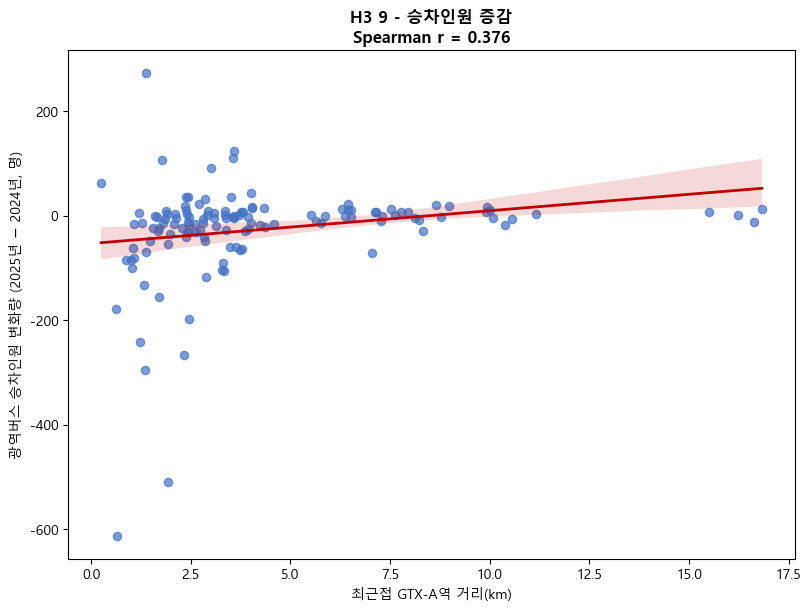

In [5]:
stable9 = pd.read_csv(OUTPUT_DIR / 'h3_9_stable_supply_demand_change.csv', encoding='utf-8-sig')
centers9 = stable9['H3 셀'].map(h3_center)
stable9[['셀 중심 위도', '셀 중심 경도']] = pd.DataFrame(centers9.tolist(), index=stable9.index)
distance_matrix9 = pd.DataFrame({station['역명']: haversine_km(stable9['셀 중심 위도'], stable9['셀 중심 경도'], station['lat'], station['lon']) for _, station in gtx_stations.iterrows()})
stable9['최근접 GTX-A역'] = distance_matrix9.idxmin(axis=1)
stable9['최근접 GTX-A역 거리(km)'] = distance_matrix9.min(axis=1)
rows9 = []
for col in demand_cols:
    pair = stable9[[distance_col, col]].dropna()
    rows9.append({'승차인원 지표': col, '표본 수': len(pair), 'Pearson 상관계수': pair[distance_col].corr(pair[col], method='pearson'), 'Spearman 상관계수': pair[distance_col].corr(pair[col], method='spearman')})
correlation_summary9 = pd.DataFrame(rows9)
print(f'H3 9 분석 셀 수: {len(stable9)}개')
display(correlation_summary9.round(3))

for col in demand_cols:
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    sns.regplot(data=stable9, x=distance_col, y=col, ax=ax, scatter_kws={'s': 35, 'alpha': 0.7, 'color': '#4472C4'}, line_kws={'color': '#C00000', 'linewidth': 2})
    r = stable9[distance_col].corr(stable9[col], method='spearman')
    ax.set_title(f'H3 9 - {col}\nSpearman r = {r:.3f}', fontweight='bold')
    ax.set_xlabel('최근접 GTX-A역 거리(km)')
    ax.set_ylabel(Y_LABEL)
    plt.show()

## H3 7 해상도 상관분석

H3 7 공급구조 유지 셀을 대상으로 최근접 GTX-A 역 거리와 승차인원 변화량의 상관관계를 확인한다.

H3 7 분석 셀 수: 20개


,승차인원 지표,표본 수,Pearson 상관계수,Spearman 상관계수
0,승차인원 증감,20,0.178,0.202


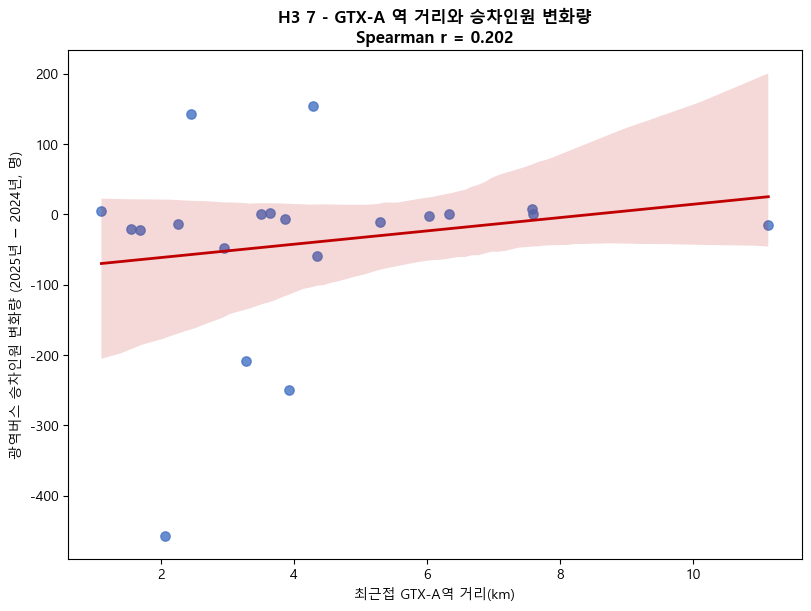

In [6]:
stable7 = pd.read_csv(OUTPUT_DIR / 'h3_7_stable_supply_demand_change.csv', encoding='utf-8-sig')
centers7 = stable7['H3 셀'].map(h3_center)
stable7[['셀 중심 위도', '셀 중심 경도']] = pd.DataFrame(centers7.tolist(), index=stable7.index)
distance_matrix7 = pd.DataFrame({station['역명']: haversine_km(stable7['셀 중심 위도'], stable7['셀 중심 경도'], station['lat'], station['lon']) for _, station in gtx_stations.iterrows()})
stable7['최근접 GTX-A역'] = distance_matrix7.idxmin(axis=1)
stable7['최근접 GTX-A역 거리(km)'] = distance_matrix7.min(axis=1)
pair7 = stable7[[distance_col, '승차인원 증감']].dropna()
summary7 = pd.DataFrame([{'승차인원 지표': '승차인원 증감', '표본 수': len(pair7), 'Pearson 상관계수': pair7[distance_col].corr(pair7['승차인원 증감'], method='pearson'), 'Spearman 상관계수': pair7[distance_col].corr(pair7['승차인원 증감'], method='spearman')}])
print(f'H3 7 분석 셀 수: {len(stable7)}개')
display(summary7.round(3))
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
sns.regplot(data=stable7, x=distance_col, y='승차인원 증감', ax=ax, scatter_kws={'s': 45, 'alpha': 0.8, 'color': '#4472C4'}, line_kws={'color': '#C00000', 'linewidth': 2})
r7 = pair7[distance_col].corr(pair7['승차인원 증감'], method='spearman')
ax.set_title(f'H3 7 - GTX-A 역 거리와 승차인원 변화량\nSpearman r = {r7:.3f}', fontweight='bold')
ax.set_xlabel('최근접 GTX-A역 거리(km)')
ax.set_ylabel(Y_LABEL)
plt.show()